# Entrenamiento con MLflow Tracking \[EJERCICIO\]

Partimos del pipeline que ya construiste en `02_training_ejercicio.ipynb`:
los pasos de carga, limpieza, feature engineering, split y entrenamiento
ya están resueltos — **no los tienes que volver a implementar**.

Tu tarea en este notebook es exclusivamente aprender a usar **MLflow**:
configurar el experimento **local** y registrar parámetros, métricas,
el modelo y un artefacto gráfico.

Completa solo las celdas marcadas con `# TODO`.

## 1. Importar librerías

El pipeline base ya lo conoces. Solo falta importar MLflow.

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score,mean_absolute_percentage_error

import mlflow

## 2. Configurar MLflow → Local \[TODO\]

Apunta el cliente MLflow al servidor local (`http://localhost:5000`).  
Asegúrate de que el servidor esté corriendo con `mlflow ui`.

In [5]:
# TODO: apuntar MLflow al servidor local (http://localhost:5000)
mlflow.set_tracking_uri("http://localhost:5000")

# TODO: definir el nombre del experimento y activarlo
EXPERIMENT_NAME = "mlops_workshop"
mlflow.set_experiment(EXPERIMENT_NAME)

print(f"Tracking URI : {mlflow.get_tracking_uri()}")
print(f"Experimento  : {EXPERIMENT_NAME}")

Tracking URI : http://localhost:5000
Experimento  : mlops_workshop


## 3–6. Pipeline de datos y entrenamiento

> Esta sección ya está resuelta — es la misma que construiste en `02_training_ejercicio.ipynb`.
> Ejecútala para tener el modelo listo antes de la sección de MLflow.

In [6]:
df = pd.read_csv("../data/raw/concrete_data.csv")
df = df.drop_duplicates().dropna()

df["water_cement_ratio"] = df["water"] / (df["cement"] + 1e-9)
df["binder_total"]       = df["cement"] + df["blast_furnace_slag"] + df["fly_ash"]
df["aggregate_total"]    = df["coarse_aggregate"] + df["fine_aggregate"]

# Split
TARGET       = "concrete_compressive_strength"
TEST_SIZE    = 0.2
RANDOM_STATE = 42

X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

# Entrenar
N_ESTIMATORS = 100
MAX_DEPTH    = None

model = RandomForestRegressor(
    n_estimators=N_ESTIMATORS,
    max_depth=MAX_DEPTH,
    random_state=RANDOM_STATE,
)
model.fit(X_train, y_train)

# Métricas
y_pred = model.predict(X_test)
mae    = mean_absolute_error(y_test, y_pred)
rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
r2     = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"MAE={mae:.3f}  RMSE={rmse:.3f}  R²={r2:.3f}  MAPE={mape:.3f}")

Train: (804, 11)  |  Test: (201, 11)
MAE=3.451  RMSE=4.953  R²=0.918  MAPE=0.124


## 4. Registrar el run en MLflow \[TODO\]

Todo lo que ocurra dentro del bloque `with mlflow.start_run()` queda guardado
en el servidor MLflow local. Tu tarea es completar las 4 llamadas de tracking:

| Paso | Método MLflow |
|---|---|
| Registrar hiperparámetros | `mlflow.log_params(dict)` |
| Registrar métricas | `mlflow.log_metrics(dict)` |
| Registrar el modelo | `mlflow.sklearn.log_model(...)` |
| Registrar la figura | `mlflow.log_figure(fig, artifact_file=...)` |

2026/05/24 08:18:27 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


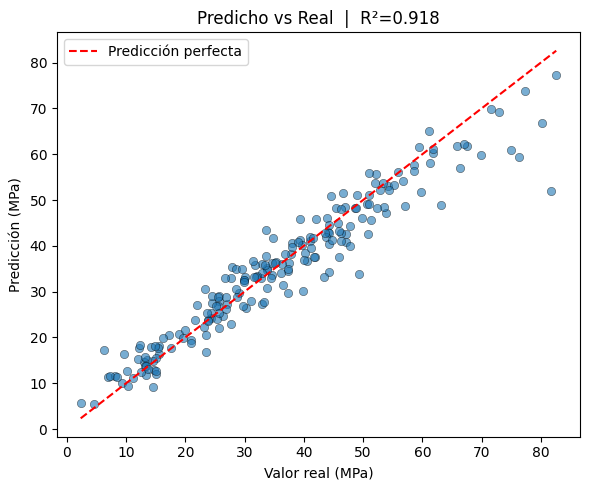

Run registrado  : 4b4d75a3302047cc897e550e2cca8a0d
MAE  : 3.451 | RMSE : 4.953 | R²  : 0.918
🏃 View run capricious-auk-281 at: http://localhost:5000/#/experiments/3/runs/4b4d75a3302047cc897e550e2cca8a0d
🧪 View experiment at: http://localhost:5000/#/experiments/3


In [7]:
with mlflow.start_run():

    # -- 1. Registrar hiperparámetros -----------------------------------------
    # TODO: loguear n_estimators, max_depth, test_size y random_state
    mlflow.log_param("num_estimators", N_ESTIMATORS)
    mlflow.log_param("max_depth", MAX_DEPTH)
    mlflow.log_param("test_size", TEST_SIZE)
    mlflow.log_param("random_state", RANDOM_STATE)
    
    # -- 2. Registrar métricas ------------------------------------------------
    # TODO: loguear mae, rmse y r2 (ya calculados arriba)
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("r2", r2)
    mlflow.log_metric("mape", mape)

    # -- 3. Registrar el modelo -----------------------------------------------
    #X_train_f64 = X_train.astype("float64")
    #signature   = mlflow.models.infer_signature(X_train_f64, model.predict(X_train))

    # TODO: loguear el modelo con su firma y un input_example de 5 filas
    mlflow.sklearn.log_model(
        sk_model=model
    )

    # -- 4. Registrar figura predicho vs real ---------------------------------
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(y_test, y_pred, alpha=0.6, edgecolors="k", linewidths=0.4)
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, "r--", linewidth=1.5, label="Predicción perfecta")
    ax.set_xlabel("Valor real (MPa)")
    ax.set_ylabel("Predicción (MPa)")
    ax.set_title(f"Predicho vs Real  |  R²={r2:.3f}")
    ax.legend()
    plt.tight_layout()

    # TODO: loguear la figura como artefacto PNG
    mlflow.log_figure(fig, "predicted_vs_real.png")

    plt.show()

    run_id = mlflow.active_run().info.run_id
    print(f"Run registrado  : {run_id}")
    print(f"MAE  : {mae:.3f} | RMSE : {rmse:.3f} | R²  : {r2:.3f}")